# Reactive PH Flash: Isenthalpic and Isentropic Flash with Chemical Reactions

This notebook demonstrates NeqSim's **reactive PH flash** — finding the equilibrium temperature
when pressure and total enthalpy (or entropy) are specified, while simultaneously satisfying
chemical equilibrium.

The solver uses a **secant + bisection hybrid** on temperature, wrapping an inner reactive TP flash
(Modified RAND method) at each iteration. This combination is state-of-the-art:
- The secant method captures the full effective dH/dT including reaction enthalpy contributions
- Bisection provides guaranteed convergence when a bracket is found
- The inner RAND solver handles arbitrary multiphase, multi-reaction systems

**Examples covered:**
1. Water-gas shift (WGS) PH flash round-trip
2. Steam methane reforming (SMR) — strongly endothermic
3. Ammonia synthesis — exothermic at high pressure
4. PS flash (isentropic) round-trip
5. Enthalpy vs. temperature curve with PH flash recovery points
6. Convergence behaviour — iterations vs. perturbation size
7. Adiabatic reactor outlet temperature

In [1]:
# Setup: Load NeqSim
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim3\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim3\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim3\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
# Import classes
import jpype
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if NEQSIM_MODE == "devtools":
    SystemSrkEos = ns.SystemSrkEos
    ThermodynamicOperations = ns.ThermodynamicOperations
elif NEQSIM_MODE == "pip":
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

# Reactive flash classes
ReactiveMultiphaseTPflash = jpype.JClass(
    "neqsim.thermodynamicoperations.flashops.reactiveflash.ReactiveMultiphaseTPflash")
ReactiveMultiphasePHflash = jpype.JClass(
    "neqsim.thermodynamicoperations.flashops.reactiveflash.ReactiveMultiphasePHflash")

print("All classes loaded successfully")

All classes loaded successfully


## Example 1: Water-Gas Shift (WGS) — PH Flash Round-Trip

CO + H₂O ⇌ CO₂ + H₂  (ΔH ≈ −41 kJ/mol, mildly exothermic)

We run a reactive TP flash at a known temperature to get the equilibrium enthalpy, then
perturb the temperature and use PH flash to recover it.

In [3]:
# Create WGS system at 800 K, 10 bar
system = SystemSrkEos(800.0, 10.0)
system.addComponent("CO", 0.3)
system.addComponent("water", 0.3)
system.addComponent("CO2", 0.2)
system.addComponent("hydrogen", 0.2)
system.setMixingRule("classic")

# Step 1: Reactive TP flash to find equilibrium at 800 K
tpFlash = ReactiveMultiphaseTPflash(system)
tpFlash.run()
system.init(2)

Hspec = float(system.getEnthalpy())
T_target = float(system.getTemperature())
print(f"Target T = {T_target:.2f} K")
print(f"Target H = {Hspec:.4e} J")

# Step 2: Perturb temperature to 600 K
system.setTemperature(600.0)

# Step 3: PH flash to recover the temperature
phFlash = ReactiveMultiphasePHflash(system, Hspec)
phFlash.run()

T_recovered = float(system.getTemperature())
H_final = float(system.getEnthalpy())
print(f"\nRecovered T = {T_recovered:.4f} K (target: {T_target:.2f} K)")
print(f"Error = {abs(T_recovered - T_target):.2e} K")
print(f"Converged: {phFlash.isConverged()}")
print(f"Outer iterations: {phFlash.getOuterIterations()}")
print(f"Enthalpy match: H_final = {H_final:.4e} J (target: {Hspec:.4e} J)")

Target T = 800.00 K
Target H = 3.7673e+04 J

Recovered T = 800.0000 K (target: 800.00 K)
Error = 0.00e+00 K
Converged: True
Outer iterations: 4
Enthalpy match: H_final = 3.7673e+04 J (target: 3.7673e+04 J)


## Example 2: Steam Methane Reforming (SMR) — Strongly Endothermic

CH₄ + H₂O ⇌ CO + 3H₂  (ΔH ≈ +206 kJ/mol)
CO + H₂O ⇌ CO₂ + H₂   (ΔH ≈ −41 kJ/mol)

The PH flash must handle two simultaneous reactions with strongly endothermic enthalpy.
This is a challenging case because the effective dH/dT (including reaction shift)
is much larger than the sensible heat capacity Cp alone.

In [4]:
# SMR system at 1100 K, 1 bar
system2 = SystemSrkEos(1100.0, 1.0)
system2.addComponent("methane", 0.20)
system2.addComponent("water", 0.30)
system2.addComponent("CO", 0.15)
system2.addComponent("CO2", 0.10)
system2.addComponent("hydrogen", 0.25)
system2.setMixingRule("classic")

# TP flash at 1100 K
tpFlash2 = ReactiveMultiphaseTPflash(system2)
tpFlash2.run()
system2.init(2)

Hspec2 = float(system2.getEnthalpy())
T_target2 = float(system2.getTemperature())
print(f"Target T = {T_target2:.2f} K")
print(f"Target H = {Hspec2:.4e} J")
print(f"Cp at equilibrium = {float(system2.getCp()):.4f} J/K")

# Perturb temperature by 200 K (900 K -> 1100 K recovery)
system2.setTemperature(900.0)

# PH flash recovery
phFlash2 = ReactiveMultiphasePHflash(system2, Hspec2)
phFlash2.run()

T_recovered2 = float(system2.getTemperature())
print(f"\nRecovered T = {T_recovered2:.4f} K (target: {T_target2:.2f} K)")
print(f"Error = {abs(T_recovered2 - T_target2):.2e} K")
print(f"Converged: {phFlash2.isConverged()}")
print(f"Outer iterations: {phFlash2.getOuterIterations()}")
print(f"Total inner iterations: {phFlash2.getTotalInnerIterations()}")

Target T = 1100.00 K
Target H = 5.2234e+04 J
Cp at equilibrium = 67.8584 J/K

Recovered T = 1100.0002 K (target: 1100.00 K)
Error = 1.87e-04 K
Converged: True
Outer iterations: 8
Total inner iterations: 317


## Example 3: Ammonia Synthesis — Exothermic at High Pressure

N₂ + 3H₂ ⇌ 2NH₃  (ΔH ≈ −92 kJ/mol)

At 100 bar, pressure effects are significant — higher pressure favours NH₃ formation
(Le Chatelier: fewer moles on the product side). The PH flash correctly handles this.

In [5]:
# Ammonia system at 500 K, 100 bar
system3 = SystemSrkEos(500.0, 100.0)
system3.addComponent("nitrogen", 0.25)
system3.addComponent("hydrogen", 0.75)
system3.setMixingRule("classic")

# TP flash at 500 K
tpFlash3 = ReactiveMultiphaseTPflash(system3)
tpFlash3.run()
system3.init(2)

Hspec3 = float(system3.getEnthalpy())
T_target3 = float(system3.getTemperature())
print(f"Target T = {T_target3:.2f} K")
print(f"Target H = {Hspec3:.4e} J")

# Perturb to 700 K
system3.setTemperature(700.0)

# PH flash
phFlash3 = ReactiveMultiphasePHflash(system3, Hspec3)
phFlash3.run()

T_recovered3 = float(system3.getTemperature())
print(f"\nRecovered T = {T_recovered3:.4f} K (target: {T_target3:.2f} K)")
print(f"Error = {abs(T_recovered3 - T_target3):.2e} K")
print(f"Converged: {phFlash3.isConverged()}")
print(f"Outer iterations: {phFlash3.getOuterIterations()}")

Target T = 500.00 K
Target H = 1.3411e+04 J

Recovered T = 500.0000 K (target: 500.00 K)
Error = 3.36e-07 K
Converged: True
Outer iterations: 5


## Example 4: PS Flash — Isentropic (Entropy Specification)

Instead of enthalpy, we specify entropy to find the equilibrium temperature.
This is useful for isentropic processes like ideal turbine/compressor modelling.

In [6]:
# WGS system at 600 K, 5 bar
system4 = SystemSrkEos(600.0, 5.0)
system4.addComponent("CO", 0.3)
system4.addComponent("water", 0.3)
system4.addComponent("CO2", 0.2)
system4.addComponent("hydrogen", 0.2)
system4.setMixingRule("classic")

# TP flash at 600 K -> get S_target
tpFlash4 = ReactiveMultiphaseTPflash(system4)
tpFlash4.run()
system4.init(2)

Sspec4 = float(system4.getEntropy())
T_target4 = float(system4.getTemperature())
print(f"Target T = {T_target4:.2f} K")
print(f"Target S = {Sspec4:.4e} J/K")

# Perturb to 500 K
system4.setTemperature(500.0)

# PS flash
psFlash = ReactiveMultiphasePHflash(system4, 0.0)  # Hspec ignored when entropy is set
psFlash.setEntropySpec(Sspec4)
psFlash.run()

T_recovered4 = float(system4.getTemperature())
S_final = float(system4.getEntropy())
print(f"\nRecovered T = {T_recovered4:.4f} K (target: {T_target4:.2f} K)")
print(f"Error = {abs(T_recovered4 - T_target4):.2e} K")
print(f"Converged: {psFlash.isConverged()}")
print(f"Entropy match: S_final = {S_final:.4e} J/K (target: {Sspec4:.4e} J/K)")

Target T = 600.00 K
Target S = 4.6956e+01 J/K

Recovered T = 600.0001 K (target: 600.00 K)
Error = 7.96e-05 K
Converged: True
Entropy match: S_final = 4.6956e+01 J/K (target: 4.6956e+01 J/K)


## Example 5: Enthalpy vs. Temperature Curve with PH Flash Recovery

We sweep temperature, run reactive TP flash at each T, and plot H(T).
Then pick several enthalpy values and use PH flash to recover the temperature.

H = 1.5615e+04 J -> T_true = 500 K, T_recovered = 500.00 K, error = 0.000 K, converged = True, iter = 6
H = 2.6598e+04 J -> T_true = 650 K, T_recovered = 650.00 K, error = 0.000 K, converged = True, iter = 3
H = 3.7673e+04 J -> T_true = 800 K, T_recovered = 800.00 K, error = 0.000 K, converged = True, iter = 2
H = 4.8907e+04 J -> T_true = 950 K, T_recovered = 950.00 K, error = 0.000 K, converged = True, iter = 5
H = 6.0464e+04 J -> T_true = 1100 K, T_recovered = 1100.00 K, error = 0.000 K, converged = True, iter = 8


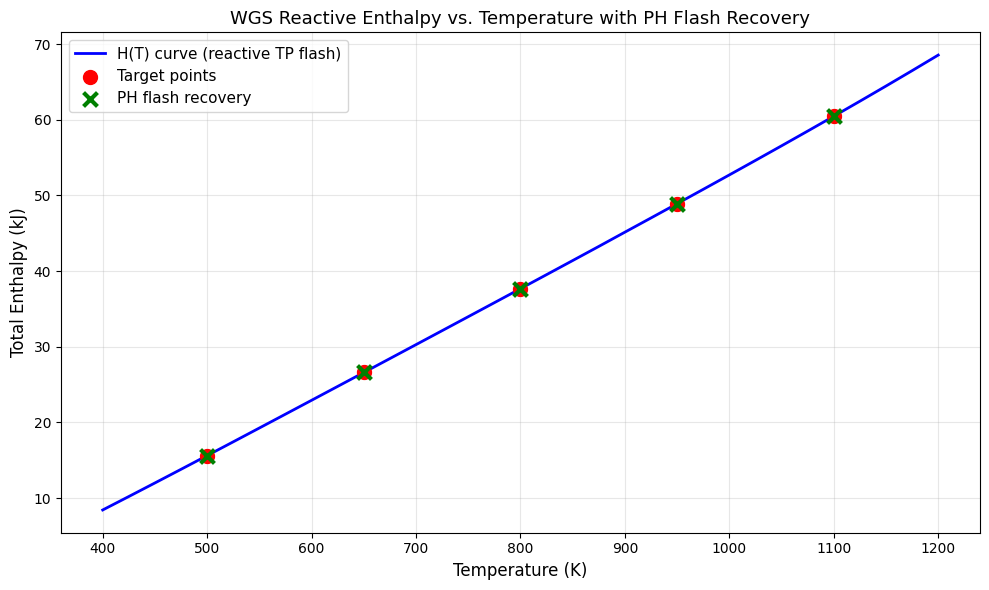

In [7]:
# WGS system — sweep T from 400 K to 1200 K
temperatures = np.arange(400, 1201, 25)
enthalpies = []

for T in temperatures:
    sys_sweep = SystemSrkEos(float(T), 10.0)
    sys_sweep.addComponent("CO", 0.3)
    sys_sweep.addComponent("water", 0.3)
    sys_sweep.addComponent("CO2", 0.2)
    sys_sweep.addComponent("hydrogen", 0.2)
    sys_sweep.setMixingRule("classic")

    tf = ReactiveMultiphaseTPflash(sys_sweep)
    tf.run()
    sys_sweep.init(2)
    enthalpies.append(float(sys_sweep.getEnthalpy()))

# Now pick 5 enthalpy values and recover T via PH flash
test_indices = [4, 10, 16, 22, 28]  # Spread across the range
recovered_T = []
recovered_H = []

for idx in test_indices:
    Htest = enthalpies[idx]
    T_true = temperatures[idx]

    # Start PH flash from 700 K (a neutral starting point)
    sys_ph = SystemSrkEos(700.0, 10.0)
    sys_ph.addComponent("CO", 0.3)
    sys_ph.addComponent("water", 0.3)
    sys_ph.addComponent("CO2", 0.2)
    sys_ph.addComponent("hydrogen", 0.2)
    sys_ph.setMixingRule("classic")

    ph = ReactiveMultiphasePHflash(sys_ph, Htest)
    ph.run()

    T_rec = float(sys_ph.getTemperature())
    recovered_T.append(T_rec)
    recovered_H.append(Htest)
    print(f"H = {Htest:.4e} J -> T_true = {T_true} K, T_recovered = {T_rec:.2f} K, "
          f"error = {abs(T_rec - T_true):.3f} K, converged = {ph.isConverged()}, "
          f"iter = {ph.getOuterIterations()}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(temperatures, np.array(enthalpies) / 1000.0, 'b-', linewidth=2, label='H(T) curve (reactive TP flash)')
ax.scatter([temperatures[i] for i in test_indices],
           np.array([enthalpies[i] for i in test_indices]) / 1000.0,
           color='red', s=100, zorder=5, marker='o', label='Target points')
ax.scatter(recovered_T, np.array(recovered_H) / 1000.0,
           color='green', s=100, zorder=5, marker='x', linewidths=3, label='PH flash recovery')
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Total Enthalpy (kJ)', fontsize=12)
ax.set_title('WGS Reactive Enthalpy vs. Temperature with PH Flash Recovery', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 6: Convergence Behaviour — Iterations vs. Perturbation Size

How many outer iterations does the PH flash need for increasing temperature perturbations?
We test WGS at 800 K with starting guesses from 400 K to 1200 K.

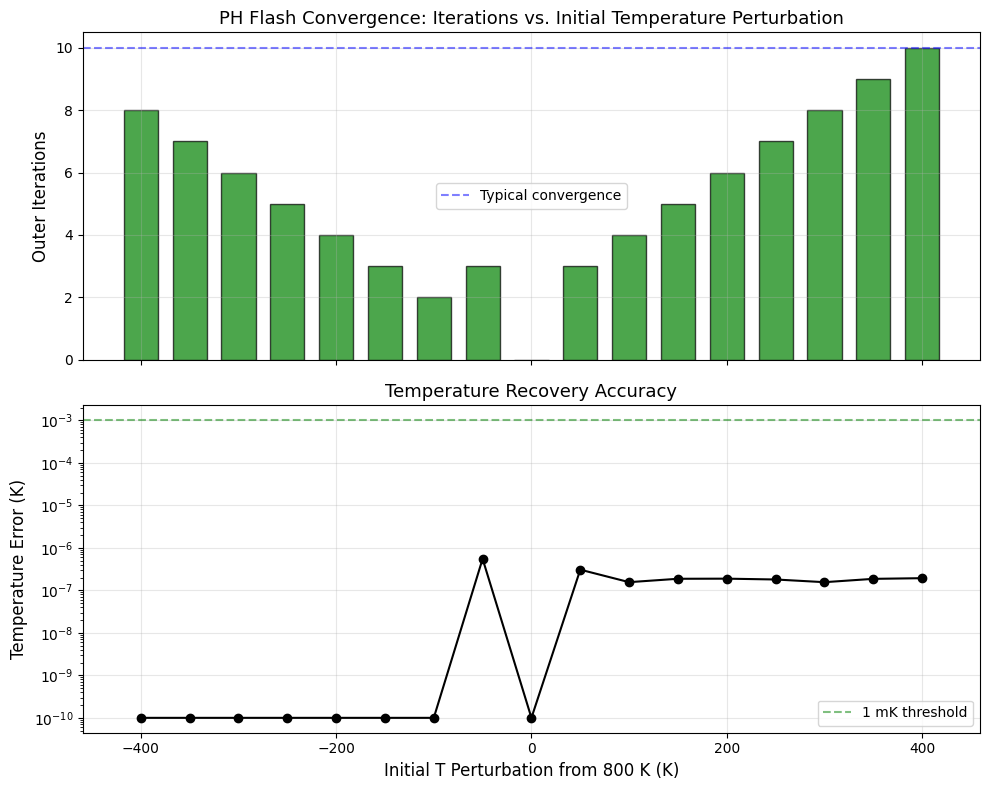

 Start T (K)  Perturbation (K)  Iterations  Converged T Error (K)
         400              -400           8       True    0.00e+00
         450              -350           7       True    0.00e+00
         500              -300           6       True    0.00e+00
         550              -250           5       True    0.00e+00
         600              -200           4       True    0.00e+00
         650              -150           3       True    0.00e+00
         700              -100           2       True    0.00e+00
         750               -50           3       True    5.50e-07
         800                 0           0       True    0.00e+00
         850                50           3       True    3.06e-07
         900               100           4       True    1.56e-07
         950               150           5       True    1.87e-07
        1000               200           6       True    1.88e-07
        1050               250           7       True    1.80e-07
        11

In [8]:
# Get reference enthalpy at 800 K
sys_ref = SystemSrkEos(800.0, 10.0)
sys_ref.addComponent("CO", 0.3)
sys_ref.addComponent("water", 0.3)
sys_ref.addComponent("CO2", 0.2)
sys_ref.addComponent("hydrogen", 0.2)
sys_ref.setMixingRule("classic")

tp_ref = ReactiveMultiphaseTPflash(sys_ref)
tp_ref.run()
sys_ref.init(2)
Href = float(sys_ref.getEnthalpy())

# Sweep starting temperatures
start_temps = np.arange(400, 1201, 50)
iterations_list = []
converged_list = []
T_errors = []

for T_start in start_temps:
    sys_test = SystemSrkEos(float(T_start), 10.0)
    sys_test.addComponent("CO", 0.3)
    sys_test.addComponent("water", 0.3)
    sys_test.addComponent("CO2", 0.2)
    sys_test.addComponent("hydrogen", 0.2)
    sys_test.setMixingRule("classic")

    ph = ReactiveMultiphasePHflash(sys_test, Href)
    ph.run()

    iterations_list.append(int(ph.getOuterIterations()))
    converged_list.append(bool(ph.isConverged()))
    T_errors.append(abs(float(sys_test.getTemperature()) - 800.0))

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

perturbation = start_temps - 800
colors = ['green' if c else 'red' for c in converged_list]

ax1.bar(perturbation, iterations_list, width=35, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Outer Iterations', fontsize=12)
ax1.set_title('PH Flash Convergence: Iterations vs. Initial Temperature Perturbation', fontsize=13)
ax1.axhline(y=10, color='blue', linestyle='--', alpha=0.5, label='Typical convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.semilogy(perturbation, [max(e, 1e-10) for e in T_errors], 'ko-', markersize=6)
ax2.axhline(y=1e-3, color='green', linestyle='--', alpha=0.5, label='1 mK threshold')
ax2.set_xlabel('Initial T Perturbation from 800 K (K)', fontsize=12)
ax2.set_ylabel('Temperature Error (K)', fontsize=12)
ax2.set_title('Temperature Recovery Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
df_conv = pd.DataFrame({
    'Start T (K)': start_temps,
    'Perturbation (K)': perturbation,
    'Iterations': iterations_list,
    'Converged': converged_list,
    'T Error (K)': [f'{e:.2e}' for e in T_errors]
})
print(df_conv.to_string(index=False))

## Example 7: Adiabatic Reactor Outlet Temperature

A practical application: given a reactor feed at known conditions and composition,
what is the adiabatic outlet temperature when the reaction reaches equilibrium?

WGS reactor with a feed at 500 K. The reaction is exothermic, so the outlet temperature
will be higher than 500 K when the feed composition shifts toward equilibrium.

In [9]:
# Feed at 500 K — unreacted composition (rich in CO and H2O, little CO2 and H2)
feed = SystemSrkEos(500.0, 20.0)
feed.addComponent("CO", 0.40)
feed.addComponent("water", 0.40)
feed.addComponent("CO2", 0.05)
feed.addComponent("hydrogen", 0.15)
feed.setMixingRule("classic")

# Compute feed enthalpy WITHOUT reactive flash (feed is unreacted)
from neqsim import jneqsim
ops = ThermodynamicOperations(feed)
ops.TPflash()  # Non-reactive flash to get feed properties
feed.initProperties()

H_feed = float(feed.getEnthalpy())
print(f"Feed conditions: T = {float(feed.getTemperature()):.1f} K, P = {float(feed.getPressure()):.1f} bar")
print(f"Feed enthalpy (unreacted): H = {H_feed:.4e} J")

# Now run PH flash with the feed enthalpy to find adiabatic outlet T
# The PH flash will run a reactive TP flash at each iteration, so the
# outlet will have equilibrium composition at whatever T satisfies H = H_feed.
phFlash_adiabatic = ReactiveMultiphasePHflash(feed, H_feed)
phFlash_adiabatic.run()

T_outlet = float(feed.getTemperature())
H_outlet = float(feed.getEnthalpy())
print(f"\nAdiabatic outlet T = {T_outlet:.2f} K ({T_outlet - 273.15:.2f} °C)")
print(f"Temperature rise = {T_outlet - 500.0:.2f} K")
print(f"Enthalpy balance: H_in = {H_feed:.4e} J, H_out = {H_outlet:.4e} J")
print(f"Converged: {phFlash_adiabatic.isConverged()}, Iterations: {phFlash_adiabatic.getOuterIterations()}")

# Show outlet composition
ncomp = int(feed.getNumberOfComponents())
print(f"\nOutlet composition (mole fractions):")
for i in range(ncomp):
    name = str(feed.getComponent(i).getComponentName())
    x = float(feed.getPhase(0).getComponent(i).getx())
    print(f"  {name:12s}: {x:.6f}")

Feed conditions: T = 500.0 K, P = 20.0 bar
Feed enthalpy (unreacted): H = 6.9960e+03 J

Adiabatic outlet T = 481.68 K (208.53 °C)
Temperature rise = -18.32 K
Enthalpy balance: H_in = 6.9960e+03 J, H_out = 6.9960e+03 J
Converged: True, Iterations: 3

Outlet composition (mole fractions):
  CO          : 0.033309
  water       : 0.033309
  CO2         : 0.416691
  hydrogen    : 0.516691


## Example 8: Using the Convenience API

The `ThermodynamicOperations` class provides convenience methods
`reactivePHflash(Hspec, type)` and `reactivePSflash(Sspec)` that wrap the PH flash class.

In [10]:
# Create system and find target enthalpy
sys_api = SystemSrkEos(700.0, 5.0)
sys_api.addComponent("CO", 0.3)
sys_api.addComponent("water", 0.3)
sys_api.addComponent("CO2", 0.2)
sys_api.addComponent("hydrogen", 0.2)
sys_api.setMixingRule("classic")

# Get equilibrium enthalpy at 700 K
tpf = ReactiveMultiphaseTPflash(sys_api)
tpf.run()
sys_api.init(2)
Hspec_api = float(sys_api.getEnthalpy())
Sspec_api = float(sys_api.getEntropy())

# Perturb and recover using convenience API
sys_api.setTemperature(500.0)
ops_api = ThermodynamicOperations(sys_api)
ops_api.reactivePHflash(Hspec_api, 0)

T_ph = float(sys_api.getTemperature())
print(f"PH flash via convenience API: T = {T_ph:.4f} K (target: 700 K)")

# PS flash
sys_api.setTemperature(500.0)  # Reset
ops_api2 = ThermodynamicOperations(sys_api)
ops_api2.reactivePSflash(Sspec_api)

T_ps = float(sys_api.getTemperature())
print(f"PS flash via convenience API: T = {T_ps:.4f} K (target: 700 K)")
print("\nAll examples completed successfully!")

PH flash via convenience API: T = 700.0000 K (target: 700 K)
PS flash via convenience API: T = 700.0000 K (target: 700 K)

All examples completed successfully!
